In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
import re

In [2]:
df = pd.read_csv("01_raw_crm_input_15000.csv")

print("Dataset shape:", df.shape)

Dataset shape: (15000, 14)


In [3]:
display(df.head())

,interaction_id,crm_note_id,interaction_date,rep_id,hcp_id,city,region,territory_id,hcp_specialization,therapeutic_area,drug_id,drug_name,brand_name,crm_note
0,INT000001,CRM000001,2026-01-01,REP0002,HCP00001,Ahmedabad,West,AHMEDABAD_CENTRAL,Rheumatologist,Rheumatology,DRG023,Arthrelis,Arthrelis,Saw HCP re Arthrelis. 2 patients mentioned inj...
1,INT000002,CRM000002,2026-02-28,REP0002,HCP00001,Ahmedabad,West,AHMEDABAD_CENTRAL,Rheumatologist,Rheumatology,DRG023,Arthrelis,Arthrelis,Met on Arthrelis. HCP reports fewer tolerance ...
2,INT000003,CRM000003,2026-03-04,REP0002,HCP00001,Ahmedabad,West,AHMEDABAD_CENTRAL,Rheumatologist,Rheumatology,DRG023,Arthrelis,Arthrelis,Met on Arthrelis. the previous adherence conce...
3,INT000004,CRM000004,2026-03-12,REP0002,HCP00001,Ahmedabad,West,AHMEDABAD_CENTRAL,Rheumatologist,Rheumatology,DRG023,Arthrelis,Arthrelis,The HCP reviewed recent experience with Arthre...
4,INT000005,CRM000005,2026-03-18,REP0002,HCP00001,Ahmedabad,West,AHMEDABAD_CENTRAL,Rheumatologist,Rheumatology,DRG022,Rheumorel,Rheumora,Brief discussion focused on Rheumora. payer ap...


In [4]:
#Understand the dataset
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

Number of rows: 15000
Number of columns: 14

Columns:
['interaction_id', 'crm_note_id', 'interaction_date', 'rep_id', 'hcp_id', 'city', 'region', 'territory_id', 'hcp_specialization', 'therapeutic_area', 'drug_id', 'drug_name', 'brand_name', 'crm_note']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   interaction_id      15000 non-null  object
 1   crm_note_id         15000 non-null  object
 2   interaction_date    15000 non-null  object
 3   rep_id              15000 non-null  object
 4   hcp_id              15000 non-null  object
 5   city                15000 non-null  object
 6   region              15000 non-null  object
 7   territory_id        15000 non-null  object
 8   hcp_specialization  15000 non-null  object
 9   therapeutic_area    15000 non-null  object
 10  drug_id             15000 non-null  object
 11  drug_name           15000 non-null  object
 12  brand_name          15000 non-null  object
 13  crm_note            15000 non-null  object
dtypes: object(14)
memory usage: 1.6+ MB


In [6]:
#Missing values
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})

display(
    missing.sort_values(
        "Missing Count",
        ascending=False
    )
)

,Missing Count,Missing %
interaction_id,0,0.0
crm_note_id,0,0.0
interaction_date,0,0.0
rep_id,0,0.0
hcp_id,0,0.0
city,0,0.0
region,0,0.0
territory_id,0,0.0
hcp_specialization,0,0.0
therapeutic_area,0,0.0


In [7]:
#Duplicate records
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


In [8]:
print(
    "Duplicate interaction IDs:",
    df["interaction_id"].duplicated().sum()
)

Duplicate interaction IDs: 0


In [9]:
#Check unique values
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print("Unique values:", df[col].nunique())
    print(df[col].dropna().unique()[:10])


interaction_id
Unique values: 15000
['INT000001' 'INT000002' 'INT000003' 'INT000004' 'INT000005' 'INT000006'
 'INT000007' 'INT000008' 'INT000009' 'INT000010']

crm_note_id
Unique values: 15000
['CRM000001' 'CRM000002' 'CRM000003' 'CRM000004' 'CRM000005' 'CRM000006'
 'CRM000007' 'CRM000008' 'CRM000009' 'CRM000010']

interaction_date
Unique values: 229
['2026-01-01' '2026-02-28' '2026-03-04' '2026-03-12' '2026-03-18'
 '2026-03-26' '2026-04-02' '2026-05-15' '2026-07-02' '2026-06-08']

rep_id
Unique values: 150
['REP0002' 'REP0009' 'REP0014' 'REP0057' 'REP0066' 'REP0021' 'REP0025'
 'REP0135' 'REP0137' 'REP0008']

hcp_id
Unique values: 3200
['HCP00001' 'HCP00002' 'HCP00003' 'HCP00004' 'HCP00005' 'HCP00006'
 'HCP00007' 'HCP00008' 'HCP00009' 'HCP00010']

city
Unique values: 14
['Ahmedabad' 'Bengaluru' 'Coimbatore' 'Delhi' 'Mumbai' 'Kolkata' 'Jaipur'
 'Hyderabad' 'Kochi' 'Chennai']

region
Unique values: 4
['West' 'South' 'North' 'East']

territory_id
Unique values: 34
['AHMEDABAD_CENTRAL' 'B

In [12]:
df["interaction_date"] = pd.to_datetime(
    df["interaction_date"],
    errors="coerce"
)

In [14]:
print("Start date:", df["interaction_date"].min())
print("End date:", df["interaction_date"].max())

Start date: 2026-01-01 00:00:00
End date: 2026-08-17 00:00:00


In [16]:
#Monthly CRM interaction trend
df["month"] = (
    df["interaction_date"]
    .dt.to_period("M")
    .astype(str)
)

monthly = (
    df["month"]
    .value_counts()
    .sort_index()
)

display(monthly)

,count
month,
2026-01,1850
2026-02,1714
2026-03,1965
2026-04,1983
2026-05,1979
2026-06,2140
2026-07,2271
2026-08,1098


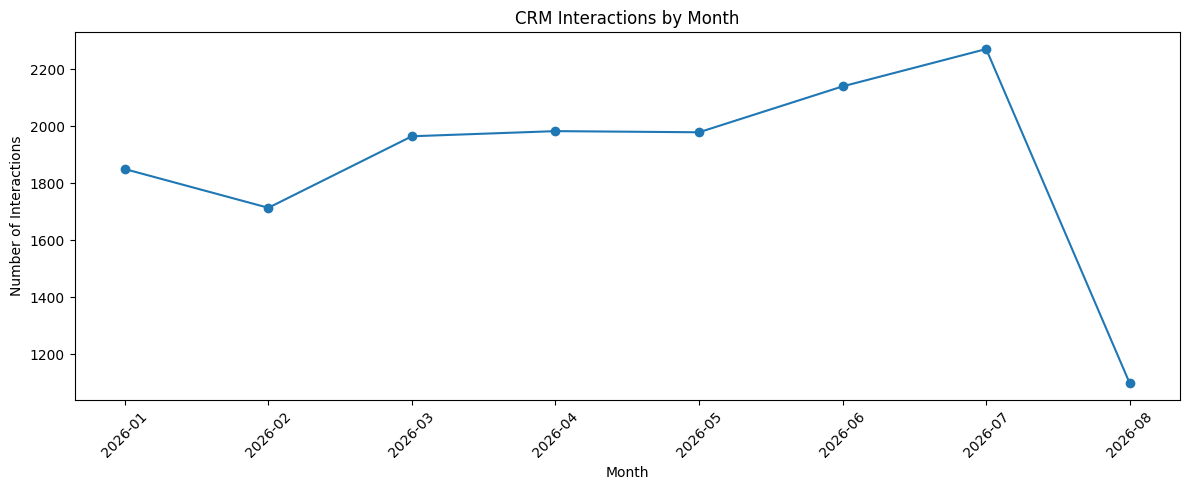

In [17]:
#Plot
plt.figure(figsize=(12, 5))

plt.plot(
    monthly.index,
    monthly.values,
    marker="o"
)

plt.title("CRM Interactions by Month")
plt.xlabel("Month")
plt.ylabel("Number of Interactions")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [19]:
#Brand distribution
brand_counts = df["brand_name"].value_counts()

display(brand_counts)

,count
brand_name,
Relivanta,1021
Vascoryn,946
Glycetra,707
Dermalune,701
MediCura,686
Cardeza,677
Pediorel,632
Metabrix,550
Pulmora,516


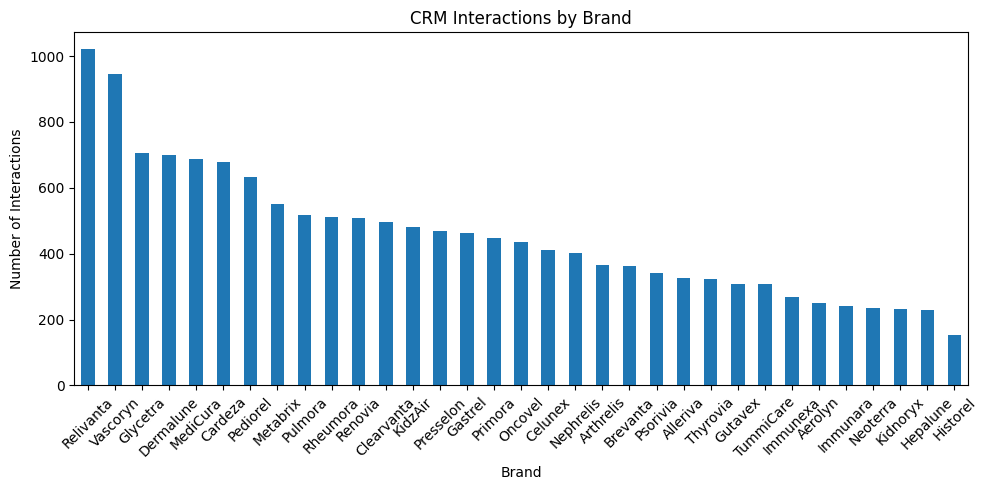

In [20]:
plt.figure(figsize=(10, 5))

brand_counts.plot(kind="bar")

plt.title("CRM Interactions by Brand")
plt.xlabel("Brand")
plt.ylabel("Number of Interactions")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()